# TASK 4 — Spam Detection with Machine Learning

**Dataset:** UCI SMS Spam Collection (5574 labelled messages).

> Note: the supplied assignment calls this "Email Spam Detection", but the recommended classic dataset is an **SMS spam** dataset. The notebook therefore accurately labels the project as spam/ham text classification.

The UCI repository describes the collection as a public dataset of labelled messages and reports 5,574 instances with no missing values.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import re
import zipfile
from pathlib import Path
from urllib.request import urlopen

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

sns.set_theme(style="whitegrid")

## 1. Download and load the UCI dataset

The code downloads the public UCI ZIP archive directly, extracts `SMSSpamCollection`, and loads the two tab-separated columns.

In [3]:
DATA_URL = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
DATA_DIR = Path("sms_spam_data")
DATA_DIR.mkdir(exist_ok=True)
zip_path = DATA_DIR / "sms_spam_collection.zip"

if not zip_path.exists():
    with urlopen(DATA_URL) as response:
        zip_path.write_bytes(response.read())

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(DATA_DIR)

data_file = DATA_DIR / "SMSSpamCollection"
df = pd.read_csv(data_file, sep="\t", header=None, names=["label", "message"])

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 2. Data inspection and class distribution

Shape: (5572, 2)

Null values:
label      0
message    0
dtype: int64

Data types:
label      object
message    object
dtype: object

Class counts:


label
ham     4825
spam     747
Name: count, dtype: int64


Class percentages:


,percentage
label,
ham,86.59
spam,13.41


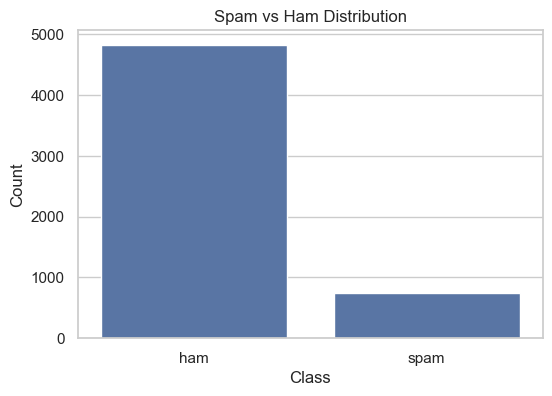

In [4]:
print("Shape:", df.shape)
print("\nNull values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

print("\nClass counts:")
display(df["label"].value_counts())

class_pct = df["label"].value_counts(normalize=True).mul(100).round(2)
print("\nClass percentages:")
display(class_pct.rename("percentage").to_frame())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="label")
plt.title("Spam vs Ham Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

## 3. Text preprocessing

The preprocessing function:
1. converts text to lowercase,
2. removes punctuation/non-letter characters,
3. collapses repeated whitespace.

Stopword removal is handled inside `TfidfVectorizer` using its English stopword list. Stemming/lemmatisation is optional and is not required for a strong baseline.

In [5]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_message"] = df["message"].apply(preprocess_text)

display(df[["label", "message", "clean_message"]].head())

,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...


## 4. What does TF-IDF measure?

**TF-IDF (Term Frequency–Inverse Document Frequency)** represents text numerically. It gives higher weight to terms that are important within a message but less common across the whole collection. Very common words receive lower weights, while informative terms receive higher weights.

This creates a sparse numerical feature matrix suitable for classical machine-learning models such as Naive Bayes and Logistic Regression.

In [6]:
X = df["clean_message"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

models = {
    "Multinomial Naive Bayes": Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=1)),
        ("model", MultinomialNB())
    ]),
    "Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=1)),
        ("model", LogisticRegression(max_iter=1000))
    ])
}

## 5. Train and evaluate two classifiers

Multinomial Naive Bayes
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       1.00      0.72      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



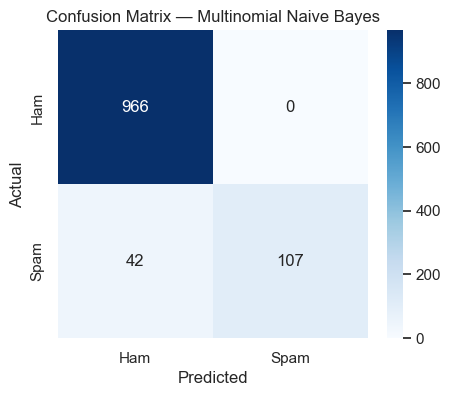

Logistic Regression
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       1.00      0.73      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.87      0.91      1115
weighted avg       0.97      0.96      0.96      1115



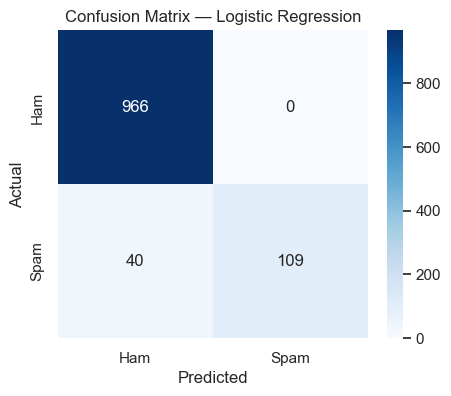

,Model,Accuracy,Precision,Recall,F1
1,Logistic Regression,0.964126,1.0,0.731544,0.844961
0,Multinomial Naive Bayes,0.962332,1.0,0.718121,0.835938


In [7]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred, pos_label="spam")
    recall = recall_score(y_test, pred, pos_label="spam")
    f1 = f1_score(y_test, pred, pos_label="spam")

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

    print("=" * 75)
    print(name)
    print(classification_report(y_test, pred))

    cm = confusion_matrix(y_test, pred, labels=["ham", "spam"])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Ham", "Spam"],
                yticklabels=["Ham", "Spam"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {name}")
    plt.show()

results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
display(results_df)

## 6. Why is recall important for spam detection?

For the **spam class**, recall measures the proportion of actual spam messages that the classifier successfully identifies as spam.

A low spam recall means many spam messages are missed and delivered as legitimate messages. In practical spam filtering, missing a large amount of spam can reduce the usefulness of the system.

However, precision also matters: a false positive can incorrectly send a legitimate message to spam. Therefore, the final model should consider **precision, recall and F1 together**, rather than accuracy alone.

## 7. Best model

In [8]:
best_row = results_df.iloc[0]
print("Best model by spam-class F1 score:", best_row["Model"])
print(f"Accuracy:  {best_row['Accuracy']:.2%}")
print(f"Precision: {best_row['Precision']:.2%}")
print(f"Recall:    {best_row['Recall']:.2%}")
print(f"F1-score:  {best_row['F1']:.2%}")

Best model by spam-class F1 score: Logistic Regression
Accuracy:  96.41%
Precision: 100.00%
Recall:    73.15%
F1-score:  84.50%


## Conclusion

This notebook completes data loading, class-distribution analysis, text preprocessing, TF-IDF feature extraction, an 80/20 stratified split, two classifiers (Multinomial Naive Bayes and Logistic Regression), accuracy/precision/recall/F1 evaluation, confusion matrices, and a discussion of why spam recall matters.